# Minimum Feature Size vs. Number of Elements Sweep

This notebook visualizes focusing efficiency as a function of both the minimum feature size (MFS) and the number of cascade elements. It loads results from the `fig2b_Nelem_min_feature_sweep` study and shows how relaxing the minimum feature size constraint (i.e., making fabrication easier) can be compensated by adding more elements to the cascade, maintaining or improving efficiency compared to a single Fresnel zone plate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))
from src.util import colors_list


In [3]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

In [4]:
fzp_color = (np.float64(0.4), np.float64(0.6509803921568628), np.float64(0.11764705882352941), np.float64(1.0))

In [5]:
path = repo_root / "paper_data"

results = []
N_runs = 3
for i in range(N_runs):
    res = np.load(path / f"fig2b_Nelem_min_feature_sweep_results_run_{i}.npz", allow_pickle=True)
    results.append(res)
params = np.load(path / "fig2b_Nelem_min_feature_sweep_params.npy", allow_pickle=True).item()
sweep_arrs = np.load(path / "fig2b_Nelem_min_feature_sweep_sweep_arrays.npy", allow_pickle=True).item()

In [6]:
mfs = sweep_arrs["min_feature_size"]
Nelems = sweep_arrs["Nelem"]

In [7]:
slc = np.s_[2:7]

In [8]:
opt_efficiencies = np.zeros((N_runs, Nelems.shape[0], len(mfs)))
fzp_efficiencies = np.zeros((N_runs, Nelems.shape[0], len(mfs)))
opt_widths = np.zeros((N_runs, Nelems.shape[0], len(mfs)))
fzp_widths = np.zeros((N_runs, Nelems.shape[0], len(mfs)))


for i in range(N_runs):
    opt_efficiencies[i] = results[i]["opt_efficiencies"]
    fzp_efficiencies[i] = results[i]["fzp_efficiencies"]
    opt_widths[i] = results[i]["opt_widths"]
    fzp_widths[i] = results[i]["fzp_widths"]

In [9]:
opt_efficiencies_mean = np.mean(opt_efficiencies, axis=0)
opt_efficiencies_std = np.std(opt_efficiencies, axis=0)

opt_widths_mean = np.mean(opt_widths, axis=0)
opt_widths_std = np.std(opt_widths, axis=0)

In [10]:
colors = colors_list(len(Nelems))

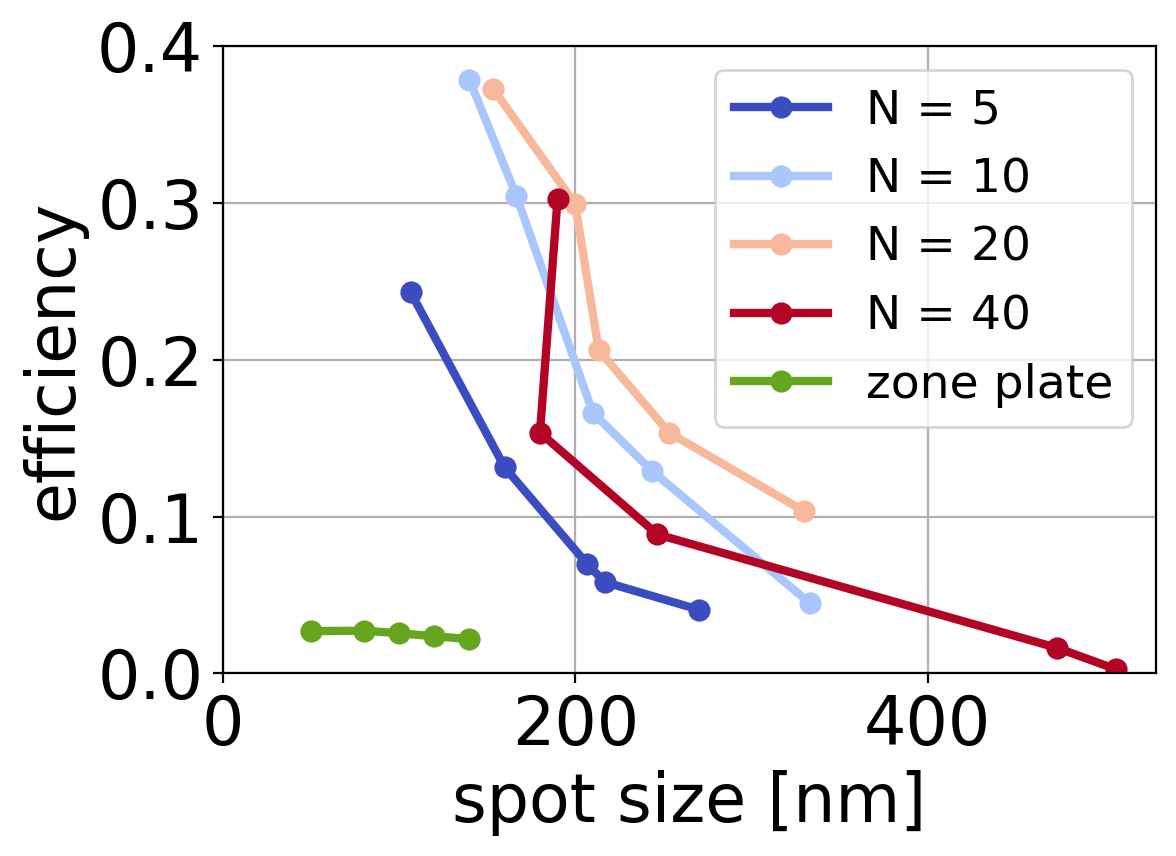

In [11]:
for i in range(len(Nelems)):
    plt.plot((opt_widths_mean[i, slc]*params['dx']*1e9), opt_efficiencies_mean[i, slc],
             label=f'N = {Nelems[i]}', linewidth=3, marker='o', markersize=7, color=colors[i])

plt.plot((fzp_widths[0, 0, slc]*params['dx']*1e9), fzp_efficiencies[0, 0, slc],
         label='zone plate', linewidth=3, marker='o', markersize=7, color=fzp_color)

plt.legend(fontsize=17, ncol=1, labelspacing=0.5, columnspacing=0.5)
plt.xlabel("spot size [nm]")
plt.ylabel("efficiency")
plt.xlim(0, None)
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()